<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/nn_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [129]:
# installs, imports
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms

!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", path)
print()

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

!pip install py3Dmol
import py3Dmol


# config
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

batch_size = 64
learning_rate = 1e-3
weight_decay = 1e-4
epochs = 24


# util
def rand_index(dataset):
  return torch.randint(0, len(dataset), (1,)).item()

def smiles_to_formula(smiles):
  return rdMolDescriptors.CalcMolFormula(Chem.MolFromSmiles(smiles))

def smiles_to_img(smiles):
  mol = Chem.MolFromSmiles(smiles)
  return Draw.MolToImage(mol)

def smiles_to_3d_obj(smiles):
  mol = Chem.MolFromSmiles(smiles)
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  AllChem.MMFFOptimizeMolecule(mol)
  return mol

def smiles_to_fp(smiles):
  mol = Chem.MolFromSmiles(smiles)
  fp = fp_gen.GetFingerprint(mol)

  fp_tensor = torch.zeros(2048)
  for j, bit in enumerate(fp):
    fp_tensor[j] = bit

  return fp_tensor


Using Colab cache for faster access to the 'lipophilicity' dataset.
Path to dataset: /kaggle/input/lipophilicity/Lipophilicity.csv



### Data

In [130]:
# data
class LipophilicityDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
      if torch.is_tensor(i):
        i = i.tolist()

      fp_tensor = smiles_to_fp(self.data.loc[i, "RDKIT_SMILES"])
      exp = self.data.loc[i, "exp"]

      return (fp_tensor, exp)

    def get_data(self):
      return self.data

dataset = LipophilicityDataset(path)

training_data, test_data = torch.utils.data.random_split(dataset, [0.85, 0.15])

training_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

### Data Examples

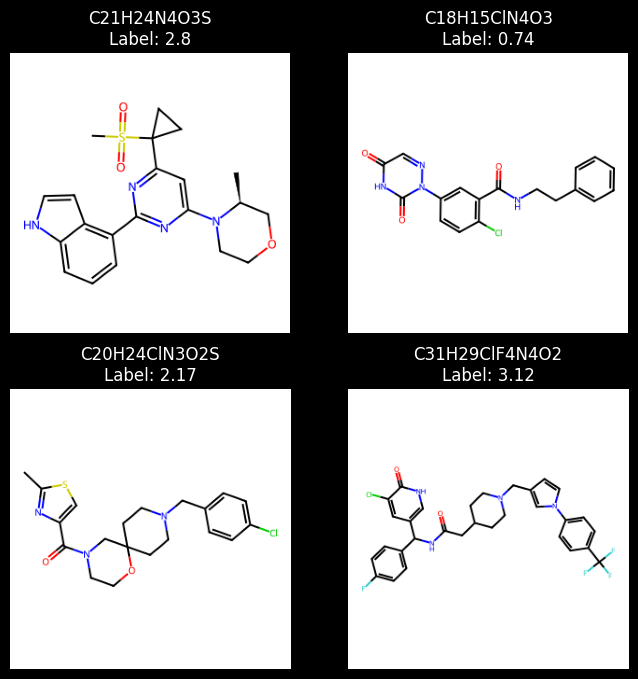

In [131]:
# data examples structural formulas
plt.style.use('dark_background')
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)

    data = pd.read_csv(path)
    rand_index = torch.randint(0, len(training_data)-4, (1,)).item()
    smiles = data.loc[rand_index, "RDKIT_SMILES"]
    formula = smiles_to_formula(smiles)
    label = data.loc[rand_index, "exp"]
    image = smiles_to_img(smiles)
    plt.imshow(image)
    plt.title(f"{formula}\nLabel: {label}")
    plt.axis("off")

In [132]:
# data examples 3d objects

# data = pd.read_csv(path)

# view = py3Dmol.view(viewergrid=(2, 2), width=800, height=800)
# view.setBackgroundColor('black')

# for i in range(4):
#   viewer = (i%2, i//2)
#   rand_index = torch.randint(0, len(training_data), (1,)).item()
#   mol_3d = smiles_to_3d_obj(data.loc[rand_index, "RDKIT_SMILES"])
#   view.addModel(Chem.MolToMolBlock(mol_3d), "mol", viewer=viewer)
#   view.addLabel(f"Label: {data.loc[rand_index, 'exp']}", {"position":{"x":0,"y":0,"z":0}}, viewer=viewer)
#   view.zoomTo()

# view.setStyle({
#   "stick": {},
#   "sphere":{"scale":0.35},
#   })

# view.show()

### Model

In [133]:
# model
class NeuralNet(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.net = nn.Sequential(
      nn.Linear(2048, 1024),
      nn.ReLU(),
      nn.BatchNorm1d(1024),
      nn.Dropout(0.2),

      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.BatchNorm1d(512),
      nn.Dropout(0.3),

      nn.Linear(512, 128),
      nn.ReLU(),
      nn.Linear(128, 1)
      )

  def forward(self, x):
        return self.net(x)

model = NeuralNet()


### Training and Testing

Initial Model Performance:
Evaluate
[    0/ 3570]
[  320/ 3570]
[  640/ 3570]
[  960/ 3570]
[ 1280/ 3570]
[ 1600/ 3570]
[ 1920/ 3570]
[ 2240/ 3570]
[ 2560/ 3570]
[ 2880/ 3570]
[ 3200/ 3570]
[ 2750/ 3570]
[ 3570/ 3570]
Average loss (training data): 6.020342

Evaluate
[    0/  630]
[  320/  630]
[  630/  630]
Average loss (test data): 5.855489

Eppoch 1/24
loss: 5.537005  [    0/ 3570]
loss: 4.857346  [  320/ 3570]
loss: 1.763360  [  640/ 3570]
loss: 1.185421  [  960/ 3570]
loss: 1.251969  [ 1280/ 3570]
loss: 1.483378  [ 1600/ 3570]
loss: 1.123667  [ 1920/ 3570]
loss: 0.807302  [ 2240/ 3570]
loss: 0.746909  [ 2560/ 3570]
loss: 0.863116  [ 2880/ 3570]
loss: 1.158607  [ 3200/ 3570]
loss: 0.579880  [ 2750/ 3570]

Evaluate
[    0/ 3570]
[  320/ 3570]
[  640/ 3570]
[  960/ 3570]
[ 1280/ 3570]
[ 1600/ 3570]
[ 1920/ 3570]
[ 2240/ 3570]
[ 2560/ 3570]
[ 2880/ 3570]
[ 3200/ 3570]
[ 2750/ 3570]
[ 3570/ 3570]
Average loss (training data): 0.455821

Evaluate
[    0/  630]
[  320/  630]
[  630/  630]


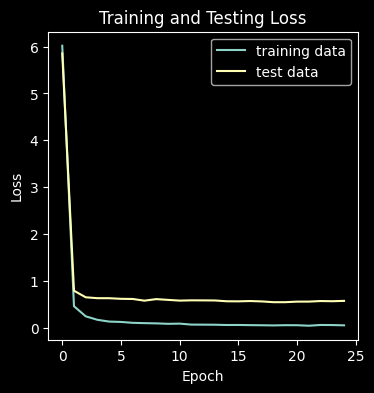

In [134]:
from torch.serialization import save
# training
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

eval_initial_performance = True
eval_between_epochs = True

save_model = True


def train(dataloader, model, loss_fn, optimizer):
  len_dataset = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    y = y.unsqueeze(1).float()
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 5 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len_dataset:>5d}]")

  print()

# testing
def evaluate(dataloader, model, loss_fn, dataset_name="test data"):
  print(f"Evaluate")
  len_dataset = len(dataloader.dataset)
  total_loss = 0

  model.eval()
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      pred = model(X)
      y = y.unsqueeze(1).float()
      total_loss += loss_fn(pred, y).item()

      if batch % 5 == 0:
        current = batch * len(X)
        print(f"[{current:>5d}/{len_dataset:>5d}]")

    total_loss = total_loss / len(dataloader)

  print(f"[{len_dataset:>5d}/{len_dataset:>5d}]")
  print(f"Average loss ({dataset_name}): {total_loss:>8f}\n")

  return total_loss


# training cycle
train_evals = []
test_evals = []

if eval_initial_performance:
  print("Initial Model Performance:")
  train_evals.append(evaluate(training_loader, model, loss_fn, dataset_name="training data"))
  test_evals.append(evaluate(test_loader, model, loss_fn, dataset_name="test data"))

for epoch in range(epochs):
  print(f"Eppoch {epoch+1}/{epochs}")
  train(training_loader, model, loss_fn, optimizer)
  if eval_between_epochs:
    train_evals.append(evaluate(training_loader, model, loss_fn, dataset_name="training data"))
    test_evals.append(evaluate(test_loader, model, loss_fn, dataset_name="test data"))

if eval_between_epochs == False:
  train_evals.append(evaluate(training_loader, model, loss_fn, dataset_name="training data"))
  test_evals.append(evaluate(test_loader, model, loss_fn, dataset_name="test data"))

print("Training and testing completed")


# total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params}')

# plot
plt.figure(figsize=(4, 4))
plt.title("Training and Testing Loss")
plt.plot(train_evals, label="training data")
plt.plot(test_evals, label="test data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# save model
if save_model:
  torch.save(model.state_dict(), 'model_weights.pth')
  torch.save(model, 'model.pth')
  print("Model saved")

### Prediction Example

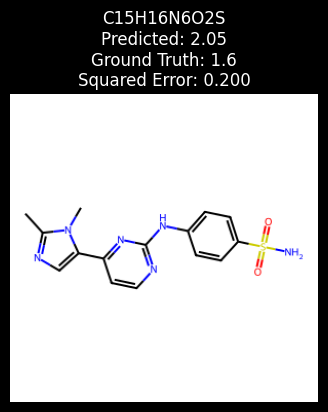

In [136]:
def pred_example(model, dataset, i=None):
  model.eval()

  # dataset argument is a Subset (like test_data). A Subset object does not have get_data(), but its underlying full dataset does.
  full_data = dataset.dataset.get_data()

  if i is None:
    idx_within_subset = torch.randint(0, len(dataset), (1,)).item()
    idx_within_full_data = dataset.indices[idx_within_subset]
  else:
    idx_within_full_data = i

  smiles = full_data.loc[idx_within_full_data, "RDKIT_SMILES"]
  image = smiles_to_img(smiles)
  formula = smiles_to_formula(smiles)
  ground_truth = full_data.loc[idx_within_full_data, "exp"]

  fp_tensor = smiles_to_fp(smiles)
  pred = model(fp_tensor.unsqueeze(0)).squeeze(0).item()
  sq_error = (pred - ground_truth)**2

  plt.figure(figsize=(4,4))
  plt.axis("off")
  plt.title(f"{formula}\nPredicted: {pred:.2f}\nGround Truth: {ground_truth}\nSquared Error: {sq_error:.3f}")

  plt.imshow(image)

pred_example(model, test_data)